# 12 — Clinical Domain Adaptation Experiments

Notebook 11 showed that longer public-data training improved clinical Dice but did not solve clinical transfer. This notebook changes from pure generalization to clinical-domain adaptation.

The question here is not whether a public-data model works unchanged on clinical images. The question is how held-out clinical performance changes when controlled fractions of clinical-domain labels are used for fine-tuning.

This notebook:

1. loads the Notebook 10 public-data-trained checkpoint,
2. creates a patient/encounter-group-safe clinical adaptation split,
3. evaluates the unadapted Notebook 10 model on the held-out clinical test groups,
4. fine-tunes separate fresh copies of the Notebook 10 model on 25%, 50%, and 75% of the clinical adaptation training pool,
5. selects each adapted model by clinical validation mean foreground Dice,
6. evaluates every condition on the same held-out clinical test groups.

Clinical data are used for adaptation in this notebook. This is no longer a pure generalization experiment.

In [1]:
# 12.01 — Imports

from __future__ import annotations

import copy
import json
import math
import os
import platform
import sys
import time
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display


In [2]:
# 12.02 — Project root and source path setup

def find_project_root(start: Path | None = None) -> Path:
    """Find the repository root by walking upward to the .git directory."""
    current = Path.cwd() if start is None else Path(start).resolve()

    for candidate in [current, *current.parents]:
        if (candidate / ".git").exists():
            return candidate

    raise FileNotFoundError("Could not find project root containing .git.")


PROJECT_ROOT = find_project_root()
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

os.chdir(PROJECT_ROOT)

print(f"Project root: {PROJECT_ROOT.name}")
print(f"Source directory available: {SRC_DIR.exists()}")
print(f"Python executable: {sys.executable}")
print(f"Python version: {platform.python_version()}")


Project root: Automated-Glaucoma-Screening-Using-AI-Enhanced-Ophthalmoscopy
Source directory available: True
Python executable: <HOME>/.conda/envs/glaucoma-capstone/bin/python
Python version: 3.11.15


In [3]:
# 12.03 — Paths and output directories

REPORTS_DIR = PROJECT_ROOT / "reports"
TRAINING_REPORT_DIR = REPORTS_DIR / "training"
DATA_AUDIT_REPORT_DIR = REPORTS_DIR / "data_audit"

PRIVATE_CLINICAL_GENERALIZATION_DIR = PROJECT_ROOT / "data/interim/private_clinical_generalization"
PRIVATE_ADAPTATION_DIR = PROJECT_ROOT / "data/interim/private_clinical_domain_adaptation"
PRIVATE_CHECKPOINT_DIR = PROJECT_ROOT / "data/interim/private_model_checkpoints/notebook_12"
PRIVATE_NOTEBOOK_10_CHECKPOINT_DIR = PROJECT_ROOT / "data/interim/private_model_checkpoints/notebook_10"

TRAINING_REPORT_DIR.mkdir(parents=True, exist_ok=True)
DATA_AUDIT_REPORT_DIR.mkdir(parents=True, exist_ok=True)
PRIVATE_ADAPTATION_DIR.mkdir(parents=True, exist_ok=True)
PRIVATE_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

NOTEBOOK_10_SUMMARY_PATH = TRAINING_REPORT_DIR / "long_training_selected_public_summary.csv"
NOTEBOOK_10_BEST_CHECKPOINT_PATH = (
    PRIVATE_NOTEBOOK_10_CHECKPOINT_DIR / "long_training_selected_public_best_state_private.pt"
)

PRIVATE_CLINICAL_MANIFEST_PATH = (
    PRIVATE_CLINICAL_GENERALIZATION_DIR / "clinical_psd_derived_mask_manifest_private.csv"
)

PRIVATE_SPLIT_MANIFEST_PATH = (
    PRIVATE_ADAPTATION_DIR / "clinical_domain_adaptation_split_manifest_private.csv"
)
PRIVATE_IMAGE_LEVEL_METRICS_PATH = (
    PRIVATE_ADAPTATION_DIR / "clinical_domain_adaptation_image_level_metrics_private.csv"
)

SPLIT_SUMMARY_PATH = DATA_AUDIT_REPORT_DIR / "clinical_domain_adaptation_split_summary.csv"
DATASET_SUMMARY_PATH = DATA_AUDIT_REPORT_DIR / "clinical_domain_adaptation_dataset_summary.csv"

PLAN_PATH = TRAINING_REPORT_DIR / "clinical_domain_adaptation_plan.csv"
HISTORY_PATH = TRAINING_REPORT_DIR / "clinical_domain_adaptation_history.csv"
RUN_METADATA_PATH = TRAINING_REPORT_DIR / "clinical_domain_adaptation_run_metadata.csv"
VALIDATION_SUMMARY_PATH = TRAINING_REPORT_DIR / "clinical_domain_adaptation_validation_summary.csv"
TEST_SUMMARY_PATH = TRAINING_REPORT_DIR / "clinical_domain_adaptation_test_summary.csv"
PATIENT_WEIGHTED_SUMMARY_PATH = TRAINING_REPORT_DIR / "clinical_domain_adaptation_patient_weighted_summary.csv"
COMPARISON_SUMMARY_PATH = TRAINING_REPORT_DIR / "clinical_domain_adaptation_comparison_summary.csv"

paths = pd.DataFrame(
    [
        {"artifact": "Notebook 10 public summary", "path": NOTEBOOK_10_SUMMARY_PATH, "exists": NOTEBOOK_10_SUMMARY_PATH.exists(), "required": True, "commit": False},
        {"artifact": "Notebook 10 private best checkpoint", "path": NOTEBOOK_10_BEST_CHECKPOINT_PATH, "exists": NOTEBOOK_10_BEST_CHECKPOINT_PATH.exists(), "required": True, "commit": False},
        {"artifact": "Notebook 08/11 private clinical manifest", "path": PRIVATE_CLINICAL_MANIFEST_PATH, "exists": PRIVATE_CLINICAL_MANIFEST_PATH.exists(), "required": True, "commit": False},
        {"artifact": "Notebook 12 private split manifest", "path": PRIVATE_SPLIT_MANIFEST_PATH, "exists": PRIVATE_SPLIT_MANIFEST_PATH.exists(), "required": False, "commit": False},
        {"artifact": "Notebook 12 private image-level metrics", "path": PRIVATE_IMAGE_LEVEL_METRICS_PATH, "exists": PRIVATE_IMAGE_LEVEL_METRICS_PATH.exists(), "required": False, "commit": False},
        {"artifact": "Notebook 12 split summary", "path": SPLIT_SUMMARY_PATH, "exists": SPLIT_SUMMARY_PATH.exists(), "required": False, "commit": True},
        {"artifact": "Notebook 12 dataset summary", "path": DATASET_SUMMARY_PATH, "exists": DATASET_SUMMARY_PATH.exists(), "required": False, "commit": True},
        {"artifact": "Notebook 12 plan", "path": PLAN_PATH, "exists": PLAN_PATH.exists(), "required": False, "commit": True},
        {"artifact": "Notebook 12 history", "path": HISTORY_PATH, "exists": HISTORY_PATH.exists(), "required": False, "commit": True},
        {"artifact": "Notebook 12 run metadata", "path": RUN_METADATA_PATH, "exists": RUN_METADATA_PATH.exists(), "required": False, "commit": True},
        {"artifact": "Notebook 12 validation summary", "path": VALIDATION_SUMMARY_PATH, "exists": VALIDATION_SUMMARY_PATH.exists(), "required": False, "commit": True},
        {"artifact": "Notebook 12 test summary", "path": TEST_SUMMARY_PATH, "exists": TEST_SUMMARY_PATH.exists(), "required": False, "commit": True},
        {"artifact": "Notebook 12 patient-weighted summary", "path": PATIENT_WEIGHTED_SUMMARY_PATH, "exists": PATIENT_WEIGHTED_SUMMARY_PATH.exists(), "required": False, "commit": True},
        {"artifact": "Notebook 12 comparison summary", "path": COMPARISON_SUMMARY_PATH, "exists": COMPARISON_SUMMARY_PATH.exists(), "required": False, "commit": True},
    ]
)

display(paths.assign(path=paths["path"].map(lambda path: str(Path(path).relative_to(PROJECT_ROOT)))))

missing_required = paths.loc[paths["required"] & ~paths["exists"], "artifact"].tolist()
if missing_required:
    raise FileNotFoundError(
        "Missing required Notebook 12 inputs. Do not rebuild silently. "
        f"Missing: {missing_required}"
    )


,artifact,path,exists,required,commit
0,Notebook 10 public summary,reports/training/long_training_selected_public...,True,True,False
1,Notebook 10 private best checkpoint,data/interim/private_model_checkpoints/noteboo...,True,True,False
2,Notebook 08/11 private clinical manifest,data/interim/private_clinical_generalization/c...,True,True,False
3,Notebook 12 private split manifest,data/interim/private_clinical_domain_adaptatio...,True,False,False
4,Notebook 12 private image-level metrics,data/interim/private_clinical_domain_adaptatio...,True,False,False
5,Notebook 12 split summary,reports/data_audit/clinical_domain_adaptation_...,True,False,True
6,Notebook 12 dataset summary,reports/data_audit/clinical_domain_adaptation_...,True,False,True
7,Notebook 12 plan,reports/training/clinical_domain_adaptation_pl...,True,False,True
8,Notebook 12 history,reports/training/clinical_domain_adaptation_hi...,True,False,True
9,Notebook 12 run metadata,reports/training/clinical_domain_adaptation_ru...,True,False,True


In [4]:
# 12.04 — Core project module import check

from glaucoma_segmentation.clinical import (
    ClinicalDerivedMaskDataset,
    evaluate_model_on_clinical_loader,
    summarize_image_level_clinical_metrics,
    summarize_patient_weighted_clinical_metrics,
)
from glaucoma_segmentation.data.dataloaders import make_segmentation_dataloader
from glaucoma_segmentation.nets.losses import DiceCELoss
from glaucoma_segmentation.nets.model_factory import build_model
from glaucoma_segmentation.training.train_loop import model_forward, run_one_epoch_with_progress
from glaucoma_segmentation.utils.device import device_summary_dict, get_device
from glaucoma_segmentation.utils.seed import seed_everything

print("Core project imports: OK")


<HOME>/.conda/envs/glaucoma-capstone/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Core project imports: OK


In [5]:
# 12.05 — Clinical adaptation configuration

SEED = 42
IMAGE_SIZE = (256, 256)
BATCH_SIZE = 4
NUM_CLASSES = 3
EPOCHS = 25
LEARNING_RATE = 3e-5
WEIGHT_DECAY = 1e-4
PIN_MEMORY = torch.cuda.is_available()

cpu_count = os.cpu_count() or 2
NUM_WORKERS = min(2, max(1, cpu_count - 1))

TEST_GROUP_FRACTION = 0.25
VALIDATION_GROUP_FRACTION = 0.15
TRAIN_FRACTIONS = [0.25, 0.50, 0.75]
PRIMARY_SELECTION_METRIC = "clinical_validation_mean_foreground_dice"
PRIMARY_REPORTING_METRIC = "heldout_test_patient_weighted_mean_foreground_dice"

FORCE_RERUN_ALL = False

seed_config = seed_everything(SEED, deterministic=False)
DEVICE = get_device()
DEVICE_INFO = device_summary_dict(DEVICE)

config = {
    "seed": SEED,
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "num_classes": NUM_CLASSES,
    "num_workers": NUM_WORKERS,
    "pin_memory": PIN_MEMORY,
    "test_group_fraction": TEST_GROUP_FRACTION,
    "validation_group_fraction": VALIDATION_GROUP_FRACTION,
    "train_fractions": TRAIN_FRACTIONS,
    "primary_selection_metric": PRIMARY_SELECTION_METRIC,
    "primary_reporting_metric": PRIMARY_REPORTING_METRIC,
    "force_rerun_all": FORCE_RERUN_ALL,
    "device": str(DEVICE),
    "seed_config": seed_config,
}

display(pd.DataFrame([config | DEVICE_INFO]))


,seed,image_size,batch_size,epochs,learning_rate,weight_decay,num_classes,num_workers,pin_memory,test_group_fraction,...,primary_selection_metric,primary_reporting_metric,force_rerun_all,device,seed_config,device_type,name,cuda_available,cuda_device_count,mps_available
0,42,"(256, 256)",4,25,0.00003,0.0001,3,2,True,0.25,...,clinical_validation_mean_foreground_dice,heldout_test_patient_weighted_mean_foreground_...,False,cuda,"SeedConfig(seed=42, deterministic=False, cudnn...",cuda,NVIDIA RTX A6000,True,1,False


## Adaptation rule

Each clinical adaptation condition starts from the same Notebook 10 checkpoint. The 25%, 50%, and 75% runs are independent fine-tuning experiments, not continued training from one another.

The clinical split is by patient/encounter group. A group cannot appear in more than one of train, validation, and held-out test. The held-out clinical test groups are fixed across every condition.

In [6]:
# 12.06 — Load Notebook 10 checkpoint and public model summary

notebook_10_summary = pd.read_csv(NOTEBOOK_10_SUMMARY_PATH)
if len(notebook_10_summary) != 1:
    raise RuntimeError(f"Expected one Notebook 10 summary row, found {len(notebook_10_summary)}.")

notebook_10_row = notebook_10_summary.iloc[0].to_dict()
checkpoint = torch.load(NOTEBOOK_10_BEST_CHECKPOINT_PATH, map_location="cpu")

model_name = str(checkpoint.get("model_name", notebook_10_row["model_name"]))
encoder_name = str(checkpoint.get("encoder_name", notebook_10_row["encoder_name"]))
encoder_weights = checkpoint.get("encoder_weights", None)
source_strategy_name = str(checkpoint.get("strategy_name", notebook_10_row["strategy_name"]))
component_strategies = str(checkpoint.get("component_strategies", notebook_10_row["component_strategies"]))
source_checkpoint_epoch = int(checkpoint.get("epoch", notebook_10_row["best_epoch_by_val_mean_foreground_dice"]))
initial_state_dict = copy.deepcopy(checkpoint["model_state_dict"])

checkpoint_context = pd.DataFrame(
    [
        {
            "source_notebook": "10_long_training_selected_public_model",
            "source_run_name": str(notebook_10_row["run_name"]),
            "checkpoint_type": checkpoint.get("checkpoint_type"),
            "checkpoint_epoch": source_checkpoint_epoch,
            "model_name": model_name,
            "encoder_name": encoder_name,
            "encoder_weights": encoder_weights,
            "source_strategy_name": source_strategy_name,
            "component_strategies": component_strategies,
            "public_test_mean_foreground_dice": float(notebook_10_row["test_mean_foreground_dice"]),
            "public_test_disc_dice": float(notebook_10_row["test_disc_dice"]),
            "public_test_cup_dice": float(notebook_10_row["test_cup_dice"]),
            "public_test_cdr_mae": float(notebook_10_row["test_cdr_mae"]),
            "clinical_data_used_in_source_training": bool(checkpoint.get("clinical_data_used", False)),
            "private_checkpoint_loaded": True,
        }
    ]
)

display(checkpoint_context)

if bool(checkpoint_context["clinical_data_used_in_source_training"].iloc[0]):
    raise RuntimeError("Notebook 10 checkpoint unexpectedly reports clinical training data usage.")


/tmp/ipykernel_37076/1658363133.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(NOTEBOOK_10_BEST_CHECKPOINT_PATH, map_location="cpu")


,source_notebook,source_run_name,checkpoint_type,checkpoint_epoch,model_name,encoder_name,encoder_weights,source_strategy_name,component_strategies,public_test_mean_foreground_dice,public_test_disc_dice,public_test_cup_dice,public_test_cdr_mae,clinical_data_used_in_source_training,private_checkpoint_loaded
0,10_long_training_selected_public_model,long_unetplusplus_resnet18_combo_affine_vignet...,best_validation,24,unetplusplus,resnet18,None,combo_affine_vignette_blur,small_affine;vignette_illumination;defocus_blur,0.842136,0.864347,0.819926,0.062985,False,True


In [7]:
# 12.07 — Build patient/encounter-group clinical adaptation split

clinical_manifest = pd.read_csv(PRIVATE_CLINICAL_MANIFEST_PATH)
ready_manifest = clinical_manifest.loc[clinical_manifest["mask_ready"].astype(bool)].copy()

if ready_manifest.empty:
    raise ValueError("No mask-ready clinical samples are available.")

required_columns = {"patient_hash", "eye"}
missing_columns = sorted(required_columns.difference(ready_manifest.columns))
if missing_columns:
    raise RuntimeError(f"Clinical manifest is missing required columns: {missing_columns}")

ready_manifest["eye"] = ready_manifest["eye"].astype(str).str.upper().replace({"NAN": "UNKNOWN"})
ready_manifest["patient_hash"] = ready_manifest["patient_hash"].astype(str)

unique_groups = sorted(ready_manifest["patient_hash"].unique().tolist())
group_count = len(unique_groups)

if len(ready_manifest) != 59:
    raise RuntimeError(f"Expected 59 mask-ready clinical rows, found {len(ready_manifest)}.")
if group_count != 20:
    raise RuntimeError(f"Expected 20 clinical patient/encounter groups, found {group_count}.")

rng = np.random.default_rng(SEED + 1200)
shuffled_groups = unique_groups.copy()
rng.shuffle(shuffled_groups)

n_test_groups = max(4, int(round(group_count * TEST_GROUP_FRACTION)))
n_val_groups = max(3, int(round(group_count * VALIDATION_GROUP_FRACTION)))

if n_test_groups + n_val_groups >= group_count:
    raise RuntimeError("Clinical test/validation group allocation leaves no adaptation training pool.")

test_groups = shuffled_groups[:n_test_groups]
val_groups = shuffled_groups[n_test_groups:n_test_groups + n_val_groups]
train_pool_groups = shuffled_groups[n_test_groups + n_val_groups:]

if not train_pool_groups:
    raise RuntimeError("Clinical adaptation training pool is empty.")

train_fraction_group_map: dict[float, list[str]] = {}
for fraction in TRAIN_FRACTIONS:
    n_fraction_groups = max(1, int(math.ceil(len(train_pool_groups) * float(fraction))))
    n_fraction_groups = min(n_fraction_groups, len(train_pool_groups))
    train_fraction_group_map[float(fraction)] = train_pool_groups[:n_fraction_groups]

split_manifest = ready_manifest.copy()
split_manifest["clinical_adaptation_base_split"] = "unused"
split_manifest.loc[split_manifest["patient_hash"].isin(test_groups), "clinical_adaptation_base_split"] = "test"
split_manifest.loc[split_manifest["patient_hash"].isin(val_groups), "clinical_adaptation_base_split"] = "validation"
split_manifest.loc[split_manifest["patient_hash"].isin(train_pool_groups), "clinical_adaptation_base_split"] = "train_pool"

for fraction, groups in train_fraction_group_map.items():
    percent = int(round(fraction * 100))
    split_manifest[f"in_train_fraction_{percent}pct"] = split_manifest["patient_hash"].isin(groups)

PRIVATE_SPLIT_MANIFEST_PATH.parent.mkdir(parents=True, exist_ok=True)
split_manifest.to_csv(PRIVATE_SPLIT_MANIFEST_PATH, index=False)

def summarize_manifest_subset(
    frame: pd.DataFrame,
    *,
    split_label: str,
    condition: str,
    train_fraction: float | None,
) -> dict[str, object]:
    eye_counts = frame["eye"].astype(str).str.upper().value_counts().to_dict()
    return {
        "condition": condition,
        "train_fraction": train_fraction,
        "split": split_label,
        "rows": int(len(frame)),
        "patient_groups": int(frame["patient_hash"].nunique()),
        "eye_od_rows": int(eye_counts.get("OD", 0)),
        "eye_os_rows": int(eye_counts.get("OS", 0)),
        "eye_unknown_rows": int(eye_counts.get("UNKNOWN", 0)),
        "contains_raw_paths": False,
        "contains_sample_hashes": False,
        "contains_patient_hashes": False,
    }

split_summary_rows: list[dict[str, object]] = []

base_split_map = {
    "test": test_groups,
    "validation": val_groups,
    "train_pool": train_pool_groups,
}
for split_label, groups in base_split_map.items():
    subset = ready_manifest.loc[ready_manifest["patient_hash"].isin(groups)].copy()
    split_summary_rows.append(
        summarize_manifest_subset(
            subset,
            split_label=split_label,
            condition="base_clinical_group_split",
            train_fraction=np.nan,
        )
    )

for fraction, groups in train_fraction_group_map.items():
    percent = int(round(fraction * 100))
    condition = f"clinical_adapt_{percent}pct"
    subset = ready_manifest.loc[ready_manifest["patient_hash"].isin(groups)].copy()
    split_summary_rows.append(
        summarize_manifest_subset(
            subset,
            split_label="train",
            condition=condition,
            train_fraction=float(fraction),
        )
    )

split_summary = pd.DataFrame(split_summary_rows)
split_summary.to_csv(SPLIT_SUMMARY_PATH, index=False)

test_set = set(test_groups)
val_set = set(val_groups)
pool_set = set(train_pool_groups)

if test_set & val_set or test_set & pool_set or val_set & pool_set:
    raise RuntimeError("Clinical split has patient/encounter group leakage.")

for fraction, groups in train_fraction_group_map.items():
    group_set = set(groups)
    if group_set & test_set or group_set & val_set:
        raise RuntimeError(f"Clinical train fraction {fraction} leaks into validation/test groups.")

display(split_summary)
print(f"Private split manifest saved: {PRIVATE_SPLIT_MANIFEST_PATH.relative_to(PROJECT_ROOT)}")
print(f"Public split summary saved: {SPLIT_SUMMARY_PATH.relative_to(PROJECT_ROOT)}")


,condition,train_fraction,split,rows,patient_groups,eye_od_rows,eye_os_rows,eye_unknown_rows,contains_raw_paths,contains_sample_hashes,contains_patient_hashes
0,base_clinical_group_split,NaN,test,19,5,5,6,8,False,False,False
1,base_clinical_group_split,NaN,validation,4,3,2,2,0,False,False,False
2,base_clinical_group_split,NaN,train_pool,36,12,14,5,17,False,False,False
3,clinical_adapt_25pct,0.25,train,16,3,5,1,10,False,False,False
4,clinical_adapt_50pct,0.50,train,22,6,7,5,10,False,False,False
5,clinical_adapt_75pct,0.75,train,27,9,12,5,10,False,False,False


Private split manifest saved: data/interim/private_clinical_domain_adaptation/clinical_domain_adaptation_split_manifest_private.csv
Public split summary saved: reports/data_audit/clinical_domain_adaptation_split_summary.csv


In [8]:
# 12.08 — Dataset, loader, checkpoint, and summary helpers

def build_model_from_notebook_10_checkpoint() -> torch.nn.Module:
    """Build a fresh model and load the Notebook 10 public-data-trained checkpoint."""
    model = build_model(
        model_name=model_name,
        in_channels=3,
        classes=NUM_CLASSES,
        encoder_name=encoder_name,
        encoder_weights=encoder_weights,
    )
    model.load_state_dict(initial_state_dict)
    return model


def make_clinical_dataset(frame: pd.DataFrame) -> ClinicalDerivedMaskDataset:
    """Build a clinical PSD-derived dataset from a private manifest slice."""
    return ClinicalDerivedMaskDataset(
        frame.copy(),
        project_root=PROJECT_ROOT,
        image_size=IMAGE_SIZE,
        require_mask_ready=True,
        validate_paths=True,
    )


def make_loader(
    dataset: ClinicalDerivedMaskDataset,
    *,
    shuffle: bool,
    seed_offset: int,
) -> Any:
    """Build a clinical DataLoader.

    The global seed is set in the configuration cell. This helper avoids passing
    optional DataLoader arguments through the project wrapper unless the wrapper
    explicitly exposes them.
    """
    _ = seed_offset
    return make_segmentation_dataloader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        drop_last=False,
    )


def mean_foreground_dice(disc_dice: float, cup_dice: float) -> float:
    """Average disc and cup Dice."""
    return float((float(disc_dice) + float(cup_dice)) / 2.0)


def clone_state_dict_to_cpu(model: torch.nn.Module) -> dict[str, torch.Tensor]:
    """Clone a model state dict to CPU memory."""
    return {
        key: value.detach().cpu().clone()
        for key, value in model.state_dict().items()
    }


def replace_condition_rows(path: Path, frame: pd.DataFrame, condition: str) -> pd.DataFrame:
    """Replace rows for one condition in a public CSV artifact."""
    path.parent.mkdir(parents=True, exist_ok=True)

    if path.exists():
        existing = pd.read_csv(path)
        if "condition" in existing.columns:
            existing = existing.loc[existing["condition"].astype(str) != str(condition)].copy()
        combined = pd.concat([existing, frame], ignore_index=True, sort=False)
    else:
        combined = frame.copy()

    combined.to_csv(path, index=False)
    return combined


def save_adaptation_checkpoint(
    path: Path,
    *,
    model: torch.nn.Module,
    optimizer: torch.optim.Optimizer | None,
    condition: str,
    train_fraction: float,
    epoch: int,
    best_metric: float,
    validation_record: dict[str, object] | None,
    checkpoint_type: str,
) -> None:
    """Save an ignored private adaptation checkpoint."""
    checkpoint_payload = {
        "checkpoint_type": checkpoint_type,
        "condition": condition,
        "train_fraction": float(train_fraction),
        "source_notebook": "10_long_training_selected_public_model",
        "source_checkpoint_epoch": source_checkpoint_epoch,
        "epoch": int(epoch),
        "best_metric": float(best_metric),
        "model_name": model_name,
        "encoder_name": encoder_name,
        "encoder_weights": encoder_weights,
        "source_strategy_name": source_strategy_name,
        "component_strategies": component_strategies,
        "image_size": IMAGE_SIZE,
        "num_classes": NUM_CLASSES,
        "clinical_data_usage": "clinical_domain_adaptation",
        "clinical_training_rows_used": int(validation_record.get("clinical_training_rows_used", 0)) if validation_record else None,
        "model_state_dict": clone_state_dict_to_cpu(model),
        "optimizer_state_dict": optimizer.state_dict() if optimizer is not None else None,
        "validation_record": validation_record,
    }
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(checkpoint_payload, path)


def condition_checkpoint_path(condition: str, checkpoint_type: str) -> Path:
    return PRIVATE_CHECKPOINT_DIR / f"{condition}_{checkpoint_type}_state_private.pt"


def condition_private_metrics_path(condition: str) -> Path:
    return PRIVATE_ADAPTATION_DIR / f"{condition}_image_level_metrics_private.csv"


def condition_train_frame(train_fraction: float) -> pd.DataFrame:
    percent = int(round(train_fraction * 100))
    column = f"in_train_fraction_{percent}pct"
    if column not in split_manifest.columns:
        raise KeyError(f"Missing split manifest column: {column}")
    return split_manifest.loc[split_manifest[column].astype(bool)].copy()


validation_frame = split_manifest.loc[
    split_manifest["clinical_adaptation_base_split"] == "validation"
].copy()
test_frame = split_manifest.loc[
    split_manifest["clinical_adaptation_base_split"] == "test"
].copy()
train_pool_frame = split_manifest.loc[
    split_manifest["clinical_adaptation_base_split"] == "train_pool"
].copy()

validation_dataset = make_clinical_dataset(validation_frame)
test_dataset = make_clinical_dataset(test_frame)
train_pool_dataset = make_clinical_dataset(train_pool_frame)

validation_loader = make_loader(validation_dataset, shuffle=False, seed_offset=1201)
test_loader = make_loader(test_dataset, shuffle=False, seed_offset=1202)

dataset_summary_rows = [
    {
        "dataset_label": "clinical_adaptation_validation",
        "condition": "all_conditions",
        "train_fraction": np.nan,
        "rows": len(validation_dataset),
        "patient_groups": validation_frame["patient_hash"].nunique(),
        "used_for": "clinical_validation_model_selection",
        "contains_raw_paths": False,
        "contains_sample_hashes": False,
        "contains_patient_hashes": False,
    },
    {
        "dataset_label": "clinical_adaptation_test",
        "condition": "all_conditions",
        "train_fraction": np.nan,
        "rows": len(test_dataset),
        "patient_groups": test_frame["patient_hash"].nunique(),
        "used_for": "heldout_clinical_test_evaluation",
        "contains_raw_paths": False,
        "contains_sample_hashes": False,
        "contains_patient_hashes": False,
    },
    {
        "dataset_label": "clinical_adaptation_train_pool",
        "condition": "all_conditions",
        "train_fraction": np.nan,
        "rows": len(train_pool_dataset),
        "patient_groups": train_pool_frame["patient_hash"].nunique(),
        "used_for": "clinical_adaptation_pool",
        "contains_raw_paths": False,
        "contains_sample_hashes": False,
        "contains_patient_hashes": False,
    },
]

for fraction in TRAIN_FRACTIONS:
    percent = int(round(fraction * 100))
    train_frame = condition_train_frame(float(fraction))
    dataset_summary_rows.append(
        {
            "dataset_label": f"clinical_adaptation_train_{percent}pct",
            "condition": f"clinical_adapt_{percent}pct",
            "train_fraction": float(fraction),
            "rows": len(train_frame),
            "patient_groups": train_frame["patient_hash"].nunique(),
            "used_for": "clinical_domain_adaptation_training",
            "contains_raw_paths": False,
            "contains_sample_hashes": False,
            "contains_patient_hashes": False,
        }
    )

dataset_summary = pd.DataFrame(dataset_summary_rows)
dataset_summary.to_csv(DATASET_SUMMARY_PATH, index=False)

display(dataset_summary)
print(f"Validation batches: {len(validation_loader)}")
print(f"Test batches: {len(test_loader)}")
print(f"Saved dataset summary: {DATASET_SUMMARY_PATH.relative_to(PROJECT_ROOT)}")
print("Notebook 12 helpers ready.")


,dataset_label,condition,train_fraction,rows,patient_groups,used_for,contains_raw_paths,contains_sample_hashes,contains_patient_hashes
0,clinical_adaptation_validation,all_conditions,NaN,4,3,clinical_validation_model_selection,False,False,False
1,clinical_adaptation_test,all_conditions,NaN,19,5,heldout_clinical_test_evaluation,False,False,False
2,clinical_adaptation_train_pool,all_conditions,NaN,36,12,clinical_adaptation_pool,False,False,False
3,clinical_adaptation_train_25pct,clinical_adapt_25pct,0.25,16,3,clinical_domain_adaptation_training,False,False,False
4,clinical_adaptation_train_50pct,clinical_adapt_50pct,0.50,22,6,clinical_domain_adaptation_training,False,False,False
5,clinical_adaptation_train_75pct,clinical_adapt_75pct,0.75,27,9,clinical_domain_adaptation_training,False,False,False


Validation batches: 1
Test batches: 5
Saved dataset summary: reports/data_audit/clinical_domain_adaptation_dataset_summary.csv
Notebook 12 helpers ready.


In [9]:
# 12.09 — Save clinical domain adaptation plan

plan_rows = [
    {
        "condition": "zero_shot_notebook_10_on_clinical_test",
        "train_fraction": 0.0,
        "model_initialization": "Notebook 10 best public-data checkpoint",
        "clinical_training_rows": 0,
        "clinical_training_groups": 0,
        "clinical_validation_rows": len(validation_dataset),
        "clinical_validation_groups": validation_frame["patient_hash"].nunique(),
        "heldout_test_rows": len(test_dataset),
        "heldout_test_groups": test_frame["patient_hash"].nunique(),
        "epochs": 0,
        "learning_rate": np.nan,
        "weight_decay": np.nan,
        "selection_metric": "none_zero_shot",
        "clinical_data_usage": "heldout_test_evaluation_only",
    }
]

for fraction in TRAIN_FRACTIONS:
    percent = int(round(fraction * 100))
    train_frame = condition_train_frame(float(fraction))
    plan_rows.append(
        {
            "condition": f"clinical_adapt_{percent}pct",
            "train_fraction": float(fraction),
            "model_initialization": "Notebook 10 best public-data checkpoint",
            "clinical_training_rows": len(train_frame),
            "clinical_training_groups": train_frame["patient_hash"].nunique(),
            "clinical_validation_rows": len(validation_dataset),
            "clinical_validation_groups": validation_frame["patient_hash"].nunique(),
            "heldout_test_rows": len(test_dataset),
            "heldout_test_groups": test_frame["patient_hash"].nunique(),
            "epochs": EPOCHS,
            "learning_rate": LEARNING_RATE,
            "weight_decay": WEIGHT_DECAY,
            "selection_metric": PRIMARY_SELECTION_METRIC,
            "clinical_data_usage": "clinical_domain_adaptation",
        }
    )

plan = pd.DataFrame(plan_rows)
plan.to_csv(PLAN_PATH, index=False)

display(plan)
print(f"Saved adaptation plan: {PLAN_PATH.relative_to(PROJECT_ROOT)}")


,condition,train_fraction,model_initialization,clinical_training_rows,clinical_training_groups,clinical_validation_rows,clinical_validation_groups,heldout_test_rows,heldout_test_groups,epochs,learning_rate,weight_decay,selection_metric,clinical_data_usage
0,zero_shot_notebook_10_on_clinical_test,0.00,Notebook 10 best public-data checkpoint,0,0,4,3,19,5,0,NaN,NaN,none_zero_shot,heldout_test_evaluation_only
1,clinical_adapt_25pct,0.25,Notebook 10 best public-data checkpoint,16,3,4,3,19,5,25,0.00003,0.0001,clinical_validation_mean_foreground_dice,clinical_domain_adaptation
2,clinical_adapt_50pct,0.50,Notebook 10 best public-data checkpoint,22,6,4,3,19,5,25,0.00003,0.0001,clinical_validation_mean_foreground_dice,clinical_domain_adaptation
3,clinical_adapt_75pct,0.75,Notebook 10 best public-data checkpoint,27,9,4,3,19,5,25,0.00003,0.0001,clinical_validation_mean_foreground_dice,clinical_domain_adaptation


Saved adaptation plan: reports/training/clinical_domain_adaptation_plan.csv


In [10]:
# 12.10 — Adaptation and held-out test evaluation helper

def add_common_context_to_summary(
    frame: pd.DataFrame,
    *,
    condition: str,
    train_fraction: float,
    checkpoint_epoch: int | float,
    source_epoch: int,
    clinical_training_rows_used: int,
    clinical_training_groups_used: int,
    clinical_validation_rows_used: int,
    clinical_validation_groups_used: int,
    clinical_test_rows: int,
    clinical_test_groups: int,
) -> pd.DataFrame:
    """Add public-safe model/run context to an aggregate metrics frame."""
    frame = frame.copy()
    frame.insert(0, "condition", condition)
    frame.insert(1, "train_fraction", float(train_fraction))
    frame.insert(2, "run_name", str(notebook_10_row["run_name"]))
    frame.insert(3, "model_name", model_name)
    frame.insert(4, "encoder_name", encoder_name)
    frame.insert(5, "source_strategy_name", source_strategy_name)
    frame.insert(6, "component_strategies", component_strategies)
    frame.insert(7, "source_checkpoint_epoch", int(source_epoch))
    frame.insert(8, "adapted_checkpoint_epoch", checkpoint_epoch)
    frame.insert(9, "clinical_training_rows_used", int(clinical_training_rows_used))
    frame.insert(10, "clinical_training_groups_used", int(clinical_training_groups_used))
    frame.insert(11, "clinical_validation_rows_used", int(clinical_validation_rows_used))
    frame.insert(12, "clinical_validation_groups_used", int(clinical_validation_groups_used))
    frame.insert(13, "heldout_test_rows", int(clinical_test_rows))
    frame.insert(14, "heldout_test_groups", int(clinical_test_groups))
    frame.insert(15, "clinical_data_usage", "clinical_domain_adaptation" if train_fraction > 0 else "heldout_test_evaluation_only")
    frame["contains_private_paths"] = False
    frame["contains_sample_hashes"] = False
    frame["contains_patient_hashes"] = False
    frame["private_image_level_metrics_committed"] = False
    return frame


def evaluate_condition_on_heldout_test(
    *,
    model: torch.nn.Module,
    condition: str,
    train_fraction: float,
    adapted_checkpoint_epoch: int | float,
    clinical_training_rows_used: int,
    clinical_training_groups_used: int,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Evaluate a model on the held-out clinical test groups and save private image-level metrics."""
    model.eval()
    image_level_metrics = evaluate_model_on_clinical_loader(
        model,
        test_loader,
        device=DEVICE,
        model_forward_fn=model_forward,
    )

    if not isinstance(image_level_metrics, pd.DataFrame):
        image_level_metrics = pd.DataFrame(image_level_metrics)

    if image_level_metrics.empty:
        raise ValueError(f"{condition} produced zero held-out clinical test metric rows.")

    image_level_metrics = image_level_metrics.copy()
    image_level_metrics.insert(0, "condition", condition)
    image_level_metrics.insert(1, "train_fraction", float(train_fraction))
    image_level_metrics.insert(2, "source_checkpoint_epoch", int(source_checkpoint_epoch))
    image_level_metrics.insert(3, "adapted_checkpoint_epoch", adapted_checkpoint_epoch)

    private_condition_metrics_path = condition_private_metrics_path(condition)
    private_condition_metrics_path.parent.mkdir(parents=True, exist_ok=True)
    image_level_metrics.to_csv(private_condition_metrics_path, index=False)

    if PRIVATE_IMAGE_LEVEL_METRICS_PATH.exists():
        existing_private_metrics = pd.read_csv(PRIVATE_IMAGE_LEVEL_METRICS_PATH)
        existing_private_metrics = existing_private_metrics.loc[
            existing_private_metrics["condition"].astype(str) != condition
        ].copy()
        combined_private_metrics = pd.concat(
            [existing_private_metrics, image_level_metrics],
            ignore_index=True,
            sort=False,
        )
    else:
        combined_private_metrics = image_level_metrics.copy()

    combined_private_metrics.to_csv(PRIVATE_IMAGE_LEVEL_METRICS_PATH, index=False)

    image_summary = summarize_image_level_clinical_metrics(image_level_metrics)
    patient_summary = summarize_patient_weighted_clinical_metrics(image_level_metrics)

    clinical_validation_rows_for_summary = len(validation_dataset) if train_fraction > 0 else 0
    clinical_validation_groups_for_summary = (
        validation_frame["patient_hash"].nunique() if train_fraction > 0 else 0
    )

    image_summary = add_common_context_to_summary(
        image_summary,
        condition=condition,
        train_fraction=train_fraction,
        checkpoint_epoch=adapted_checkpoint_epoch,
        source_epoch=source_checkpoint_epoch,
        clinical_training_rows_used=clinical_training_rows_used,
        clinical_training_groups_used=clinical_training_groups_used,
        clinical_validation_rows_used=clinical_validation_rows_for_summary,
        clinical_validation_groups_used=clinical_validation_groups_for_summary,
        clinical_test_rows=len(test_dataset),
        clinical_test_groups=test_frame["patient_hash"].nunique(),
    )
    patient_summary = add_common_context_to_summary(
        patient_summary,
        condition=condition,
        train_fraction=train_fraction,
        checkpoint_epoch=adapted_checkpoint_epoch,
        source_epoch=source_checkpoint_epoch,
        clinical_training_rows_used=clinical_training_rows_used,
        clinical_training_groups_used=clinical_training_groups_used,
        clinical_validation_rows_used=clinical_validation_rows_for_summary,
        clinical_validation_groups_used=clinical_validation_groups_for_summary,
        clinical_test_rows=len(test_dataset),
        clinical_test_groups=test_frame["patient_hash"].nunique(),
    )

    replace_condition_rows(TEST_SUMMARY_PATH, image_summary, condition)
    replace_condition_rows(PATIENT_WEIGHTED_SUMMARY_PATH, patient_summary, condition)

    return image_level_metrics, image_summary, patient_summary


def run_clinical_adaptation_condition(
    *,
    condition: str,
    train_fraction: float,
    rerun: bool = False,
) -> None:
    """Fine-tune one independent clinical adaptation condition and evaluate held-out test groups."""
    best_checkpoint_path = condition_checkpoint_path(condition, "best")
    latest_checkpoint_path = condition_checkpoint_path(condition, "latest")

    condition_outputs_exist = (
        best_checkpoint_path.exists()
        and TEST_SUMMARY_PATH.exists()
        and PATIENT_WEIGHTED_SUMMARY_PATH.exists()
        and condition_private_metrics_path(condition).exists()
    )

    if condition_outputs_exist and not rerun and not FORCE_RERUN_ALL:
        print(f"{condition}: outputs already exist. Skipping because rerun=False.")
        display(pd.read_csv(TEST_SUMMARY_PATH).loc[lambda df: df["condition"].astype(str) == condition])
        display(pd.read_csv(PATIENT_WEIGHTED_SUMMARY_PATH).loc[lambda df: df["condition"].astype(str) == condition])
        return

    train_frame = condition_train_frame(train_fraction)
    train_dataset = make_clinical_dataset(train_frame)
    train_loader = make_loader(
        train_dataset,
        shuffle=True,
        seed_offset=1300 + int(round(train_fraction * 100)),
    )

    model = build_model_from_notebook_10_checkpoint().to(DEVICE)
    criterion = DiceCELoss()
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    history_records: list[dict[str, object]] = []
    best_validation_record: dict[str, object] | None = None
    best_metric = -math.inf
    best_epoch = -1

    start_time = time.perf_counter()

    for epoch in range(1, EPOCHS + 1):
        print("=" * 100)
        print(f"{condition} | epoch {epoch:02d}/{EPOCHS:02d}")
        print("=" * 100)

        train_result = run_one_epoch_with_progress(
            model=model,
            dataloader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=DEVICE,
            epoch=epoch,
            phase="train",
            total_epochs=EPOCHS,
            leave_progress=True,
        )

        val_result = run_one_epoch_with_progress(
            model=model,
            dataloader=validation_loader,
            criterion=criterion,
            optimizer=None,
            device=DEVICE,
            epoch=epoch,
            phase="val",
            total_epochs=EPOCHS,
            leave_progress=True,
        )

        val_metric = mean_foreground_dice(val_result.disc_dice, val_result.cup_dice)

        for result in [train_result, val_result]:
            row = result.to_dict()
            row.update(
                {
                    "condition": condition,
                    "train_fraction": float(train_fraction),
                    "model_name": model_name,
                    "encoder_name": encoder_name,
                    "source_strategy_name": source_strategy_name,
                    "component_strategies": component_strategies,
                    "source_checkpoint_epoch": int(source_checkpoint_epoch),
                    "image_size": str(IMAGE_SIZE),
                    "batch_size": BATCH_SIZE,
                    "learning_rate": LEARNING_RATE,
                    "weight_decay": WEIGHT_DECAY,
                    "clinical_training_rows_used": len(train_dataset),
                    "clinical_training_groups_used": train_frame["patient_hash"].nunique(),
                    "clinical_validation_rows_used": len(validation_dataset),
                    "clinical_validation_groups_used": validation_frame["patient_hash"].nunique(),
                    "clinical_validation_mean_foreground_dice": val_metric if result.phase == "val" else np.nan,
                }
            )
            history_records.append(row)

        current_validation_record = {
            "condition": condition,
            "train_fraction": float(train_fraction),
            "run_name": str(notebook_10_row["run_name"]),
            "model_name": model_name,
            "encoder_name": encoder_name,
            "source_strategy_name": source_strategy_name,
            "component_strategies": component_strategies,
            "source_checkpoint_epoch": int(source_checkpoint_epoch),
            "best_epoch_by_clinical_validation_mean_foreground_dice": int(epoch),
            "best_clinical_val_loss": float(val_result.loss),
            "best_clinical_val_disc_dice": float(val_result.disc_dice),
            "best_clinical_val_cup_dice": float(val_result.cup_dice),
            "best_clinical_val_mean_foreground_dice": float(val_metric),
            "best_clinical_val_cdr_mae": float(val_result.cdr_mae),
            "clinical_training_rows_used": int(len(train_dataset)),
            "clinical_training_groups_used": int(train_frame["patient_hash"].nunique()),
            "clinical_validation_rows_used": int(val_result.n_images),
            "clinical_validation_batches": int(val_result.n_batches),
            "clinical_data_usage": "clinical_domain_adaptation",
            "contains_private_paths": False,
            "contains_sample_hashes": False,
            "contains_patient_hashes": False,
        }

        if val_metric > best_metric:
            best_metric = val_metric
            best_epoch = epoch
            best_validation_record = current_validation_record
            save_adaptation_checkpoint(
                best_checkpoint_path,
                model=model,
                optimizer=optimizer,
                condition=condition,
                train_fraction=train_fraction,
                epoch=epoch,
                best_metric=best_metric,
                validation_record=best_validation_record,
                checkpoint_type="best_validation",
            )
            print(f"{condition}: saved new best private checkpoint at epoch {epoch:02d}.")

        save_adaptation_checkpoint(
            latest_checkpoint_path,
            model=model,
            optimizer=optimizer,
            condition=condition,
            train_fraction=train_fraction,
            epoch=epoch,
            best_metric=best_metric,
            validation_record=best_validation_record,
            checkpoint_type="latest",
        )

        print(
            f"{condition} epoch {epoch:02d} complete | "
            f"val_loss={val_result.loss:.4f} | "
            f"val_disc_dice={val_result.disc_dice:.4f} | "
            f"val_cup_dice={val_result.cup_dice:.4f} | "
            f"val_mean_foreground_dice={val_metric:.4f} | "
            f"val_cdr_mae={val_result.cdr_mae:.4f} | "
            f"best_epoch={best_epoch:02d}"
        )

    if best_validation_record is None:
        raise RuntimeError(f"{condition} did not capture a best validation record.")

    condition_history = pd.DataFrame.from_records(history_records)
    replace_condition_rows(HISTORY_PATH, condition_history, condition)

    validation_summary = pd.DataFrame([best_validation_record])
    replace_condition_rows(VALIDATION_SUMMARY_PATH, validation_summary, condition)

    elapsed_minutes = (time.perf_counter() - start_time) / 60.0

    best_checkpoint = torch.load(best_checkpoint_path, map_location=DEVICE)
    model.load_state_dict(best_checkpoint["model_state_dict"])
    model.to(DEVICE)
    model.eval()

    _, image_summary, patient_summary = evaluate_condition_on_heldout_test(
        model=model,
        condition=condition,
        train_fraction=train_fraction,
        adapted_checkpoint_epoch=int(best_validation_record["best_epoch_by_clinical_validation_mean_foreground_dice"]),
        clinical_training_rows_used=len(train_dataset),
        clinical_training_groups_used=train_frame["patient_hash"].nunique(),
    )

    metadata = pd.DataFrame(
        [
            {
                "condition": condition,
                "train_fraction": float(train_fraction),
                "run_name": str(notebook_10_row["run_name"]),
                "model_name": model_name,
                "encoder_name": encoder_name,
                "source_strategy_name": source_strategy_name,
                "component_strategies": component_strategies,
                "source_checkpoint_epoch": int(source_checkpoint_epoch),
                "best_epoch_by_clinical_validation_mean_foreground_dice": int(
                    best_validation_record["best_epoch_by_clinical_validation_mean_foreground_dice"]
                ),
                "clinical_training_rows_used": int(len(train_dataset)),
                "clinical_training_groups_used": int(train_frame["patient_hash"].nunique()),
                "clinical_validation_rows_used": int(len(validation_dataset)),
                "clinical_validation_groups_used": int(validation_frame["patient_hash"].nunique()),
                "heldout_test_rows": int(len(test_dataset)),
                "heldout_test_groups": int(test_frame["patient_hash"].nunique()),
                "epochs_requested": EPOCHS,
                "learning_rate": LEARNING_RATE,
                "weight_decay": WEIGHT_DECAY,
                "total_fit_minutes": float(elapsed_minutes),
                "device": str(DEVICE),
                "device_name": DEVICE_INFO.get("name"),
                "clinical_data_usage": "clinical_domain_adaptation",
                "private_best_checkpoint_saved": best_checkpoint_path.exists(),
                "private_best_checkpoint_committed": False,
                "private_image_level_metrics_saved": condition_private_metrics_path(condition).exists(),
                "private_image_level_metrics_committed": False,
                "contains_private_paths": False,
                "contains_sample_hashes": False,
                "contains_patient_hashes": False,
            }
        ]
    )
    replace_condition_rows(RUN_METADATA_PATH, metadata, condition)

    display(validation_summary)
    display(image_summary)
    display(patient_summary)
    display(metadata)

    del model, optimizer, criterion

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print(f"{condition}: complete.")


print("Adaptation helper ready.")


Adaptation helper ready.


In [11]:
# 12.11 — Evaluate zero-shot Notebook 10 checkpoint on held-out clinical test groups

ZERO_SHOT_CONDITION = "zero_shot_notebook_10_on_clinical_test"
RERUN_THIS_CONDITION = False

if (
    TEST_SUMMARY_PATH.exists()
    and PATIENT_WEIGHTED_SUMMARY_PATH.exists()
    and condition_private_metrics_path(ZERO_SHOT_CONDITION).exists()
    and not RERUN_THIS_CONDITION
    and not FORCE_RERUN_ALL
):
    print(f"{ZERO_SHOT_CONDITION}: outputs already exist. Skipping because RERUN_THIS_CONDITION=False.")
    display(pd.read_csv(TEST_SUMMARY_PATH).loc[lambda df: df["condition"].astype(str) == ZERO_SHOT_CONDITION])
    display(pd.read_csv(PATIENT_WEIGHTED_SUMMARY_PATH).loc[lambda df: df["condition"].astype(str) == ZERO_SHOT_CONDITION])
else:
    zero_shot_model = build_model_from_notebook_10_checkpoint().to(DEVICE)
    zero_shot_model.eval()

    _, zero_shot_image_summary, zero_shot_patient_summary = evaluate_condition_on_heldout_test(
        model=zero_shot_model,
        condition=ZERO_SHOT_CONDITION,
        train_fraction=0.0,
        adapted_checkpoint_epoch=np.nan,
        clinical_training_rows_used=0,
        clinical_training_groups_used=0,
    )

    zero_shot_metadata = pd.DataFrame(
        [
            {
                "condition": ZERO_SHOT_CONDITION,
                "train_fraction": 0.0,
                "run_name": str(notebook_10_row["run_name"]),
                "model_name": model_name,
                "encoder_name": encoder_name,
                "source_strategy_name": source_strategy_name,
                "component_strategies": component_strategies,
                "source_checkpoint_epoch": int(source_checkpoint_epoch),
                "best_epoch_by_clinical_validation_mean_foreground_dice": np.nan,
                "clinical_training_rows_used": 0,
                "clinical_training_groups_used": 0,
                "clinical_validation_rows_used": 0,
                "clinical_validation_groups_used": 0,
                "heldout_test_rows": int(len(test_dataset)),
                "heldout_test_groups": int(test_frame["patient_hash"].nunique()),
                "epochs_requested": 0,
                "learning_rate": np.nan,
                "weight_decay": np.nan,
                "total_fit_minutes": 0.0,
                "device": str(DEVICE),
                "device_name": DEVICE_INFO.get("name"),
                "clinical_data_usage": "heldout_test_evaluation_only",
                "private_best_checkpoint_saved": False,
                "private_best_checkpoint_committed": False,
                "private_image_level_metrics_saved": condition_private_metrics_path(ZERO_SHOT_CONDITION).exists(),
                "private_image_level_metrics_committed": False,
                "contains_private_paths": False,
                "contains_sample_hashes": False,
                "contains_patient_hashes": False,
            }
        ]
    )
    replace_condition_rows(RUN_METADATA_PATH, zero_shot_metadata, ZERO_SHOT_CONDITION)

    display(zero_shot_image_summary)
    display(zero_shot_patient_summary)
    display(zero_shot_metadata)

    del zero_shot_model

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print(f"{ZERO_SHOT_CONDITION}: complete.")


,condition,train_fraction,run_name,model_name,encoder_name,source_strategy_name,component_strategies,source_checkpoint_epoch,adapted_checkpoint_epoch,clinical_training_rows_used,...,image_weighted_mean_foreground_dice_max,image_weighted_cdr_abs_error_mean,image_weighted_cdr_abs_error_median,image_weighted_cdr_abs_error_std,image_weighted_cdr_abs_error_min,image_weighted_cdr_abs_error_max,contains_private_paths,contains_sample_hashes,contains_patient_hashes,private_image_level_metrics_committed
0,zero_shot_notebook_10_on_clinical_test,0.0,long_unetplusplus_resnet18_combo_affine_vignet...,unetplusplus,resnet18,combo_affine_vignette_blur,small_affine;vignette_illumination;defocus_blur,24,NaN,0,...,0.670756,0.326381,0.38673,0.23812,0.018519,0.740741,False,False,False,False


,condition,train_fraction,run_name,model_name,encoder_name,source_strategy_name,component_strategies,source_checkpoint_epoch,adapted_checkpoint_epoch,clinical_training_rows_used,...,patient_weighted_mean_foreground_dice_max,patient_weighted_cdr_abs_error_mean,patient_weighted_cdr_abs_error_median,patient_weighted_cdr_abs_error_std,patient_weighted_cdr_abs_error_min,patient_weighted_cdr_abs_error_max,contains_private_paths,contains_sample_hashes,contains_patient_hashes,private_image_level_metrics_committed
0,zero_shot_notebook_10_on_clinical_test,0.0,long_unetplusplus_resnet18_combo_affine_vignet...,unetplusplus,resnet18,combo_affine_vignette_blur,small_affine;vignette_illumination;defocus_blur,24,NaN,0,...,0.60093,0.351044,0.362765,0.22696,0.039496,0.692099,False,False,False,False


,condition,train_fraction,run_name,model_name,encoder_name,source_strategy_name,component_strategies,source_checkpoint_epoch,best_epoch_by_clinical_validation_mean_foreground_dice,clinical_training_rows_used,...,device,device_name,clinical_data_usage,private_best_checkpoint_saved,private_best_checkpoint_committed,private_image_level_metrics_saved,private_image_level_metrics_committed,contains_private_paths,contains_sample_hashes,contains_patient_hashes
0,zero_shot_notebook_10_on_clinical_test,0.0,long_unetplusplus_resnet18_combo_affine_vignet...,unetplusplus,resnet18,combo_affine_vignette_blur,small_affine;vignette_illumination;defocus_blur,24,NaN,0,...,cuda,NVIDIA RTX A6000,heldout_test_evaluation_only,False,False,True,False,False,False,False


zero_shot_notebook_10_on_clinical_test: complete.


In [12]:
# 12.12 — Train condition: clinical_adapt_25pct

RERUN_THIS_CONDITION = False

run_clinical_adaptation_condition(
    condition="clinical_adapt_25pct",
    train_fraction=0.25,
    rerun=RERUN_THIS_CONDITION,
)


clinical_adapt_25pct | epoch 01/25


val epoch 01/25: 100%|██████████| 1/1 [00:00<00:00,  1.93it/s, loss=0.5418, disc=0.113, cup=0.320, cdr_mae=0.285]


clinical_adapt_25pct: saved new best private checkpoint at epoch 01.
clinical_adapt_25pct epoch 01 complete | val_loss=0.5418 | val_disc_dice=0.1132 | val_cup_dice=0.3202 | val_mean_foreground_dice=0.2167 | val_cdr_mae=0.2854 | best_epoch=01
clinical_adapt_25pct | epoch 02/25


val epoch 02/25: 100%|██████████| 1/1 [00:00<00:00,  2.44it/s, loss=0.5317, disc=0.118, cup=0.295, cdr_mae=0.498]


clinical_adapt_25pct epoch 02 complete | val_loss=0.5317 | val_disc_dice=0.1180 | val_cup_dice=0.2949 | val_mean_foreground_dice=0.2064 | val_cdr_mae=0.4977 | best_epoch=01
clinical_adapt_25pct | epoch 03/25


...

,condition,train_fraction,run_name,model_name,encoder_name,source_strategy_name,component_strategies,source_checkpoint_epoch,best_epoch_by_clinical_validation_mean_foreground_dice,best_clinical_val_loss,...,best_clinical_val_mean_foreground_dice,best_clinical_val_cdr_mae,clinical_training_rows_used,clinical_training_groups_used,clinical_validation_rows_used,clinical_validation_batches,clinical_data_usage,contains_private_paths,contains_sample_hashes,contains_patient_hashes
0,clinical_adapt_25pct,0.25,long_unetplusplus_resnet18_combo_affine_vignet...,unetplusplus,resnet18,combo_affine_vignette_blur,small_affine;vignette_illumination;defocus_blur,24,7,0.388007,...,0.341974,0.151315,16,3,4,1,clinical_domain_adaptation,False,False,False


,condition,train_fraction,run_name,model_name,encoder_name,source_strategy_name,component_strategies,source_checkpoint_epoch,adapted_checkpoint_epoch,clinical_training_rows_used,...,image_weighted_mean_foreground_dice_max,image_weighted_cdr_abs_error_mean,image_weighted_cdr_abs_error_median,image_weighted_cdr_abs_error_std,image_weighted_cdr_abs_error_min,image_weighted_cdr_abs_error_max,contains_private_paths,contains_sample_hashes,contains_patient_hashes,private_image_level_metrics_committed
0,clinical_adapt_25pct,0.25,long_unetplusplus_resnet18_combo_affine_vignet...,unetplusplus,resnet18,combo_affine_vignette_blur,small_affine;vignette_illumination;defocus_blur,24,7,16,...,0.71915,0.490574,0.496306,0.185573,0.195455,0.888889,False,False,False,False


,condition,train_fraction,run_name,model_name,encoder_name,source_strategy_name,component_strategies,source_checkpoint_epoch,adapted_checkpoint_epoch,clinical_training_rows_used,...,patient_weighted_mean_foreground_dice_max,patient_weighted_cdr_abs_error_mean,patient_weighted_cdr_abs_error_median,patient_weighted_cdr_abs_error_std,patient_weighted_cdr_abs_error_min,patient_weighted_cdr_abs_error_max,contains_private_paths,contains_sample_hashes,contains_patient_hashes,private_image_level_metrics_committed
0,clinical_adapt_25pct,0.25,long_unetplusplus_resnet18_combo_affine_vignet...,unetplusplus,resnet18,combo_affine_vignette_blur,small_affine;vignette_illumination;defocus_blur,24,7,16,...,0.660553,0.542934,0.494007,0.149973,0.402577,0.781145,False,False,False,False


,condition,train_fraction,run_name,model_name,encoder_name,source_strategy_name,component_strategies,source_checkpoint_epoch,best_epoch_by_clinical_validation_mean_foreground_dice,clinical_training_rows_used,...,device,device_name,clinical_data_usage,private_best_checkpoint_saved,private_best_checkpoint_committed,private_image_level_metrics_saved,private_image_level_metrics_committed,contains_private_paths,contains_sample_hashes,contains_patient_hashes
0,clinical_adapt_25pct,0.25,long_unetplusplus_resnet18_combo_affine_vignet...,unetplusplus,resnet18,combo_affine_vignette_blur,small_affine;vignette_illumination;defocus_blur,24,7,16,...,cuda,NVIDIA RTX A6000,clinical_domain_adaptation,True,False,True,False,False,False,False


clinical_adapt_25pct: complete.


In [13]:
# 12.13 — Train condition: clinical_adapt_50pct

RERUN_THIS_CONDITION = False

run_clinical_adaptation_condition(
    condition="clinical_adapt_50pct",
    train_fraction=0.50,
    rerun=RERUN_THIS_CONDITION,
)


clinical_adapt_50pct | epoch 01/25


val epoch 01/25: 100%|██████████| 1/1 [00:00<00:00,  2.41it/s, loss=0.4939, disc=0.158, cup=0.291, cdr_mae=0.438]


clinical_adapt_50pct: saved new best private checkpoint at epoch 01.
clinical_adapt_50pct epoch 01 complete | val_loss=0.4939 | val_disc_dice=0.1578 | val_cup_dice=0.2908 | val_mean_foreground_dice=0.2243 | val_cdr_mae=0.4381 | best_epoch=01
clinical_adapt_50pct | epoch 02/25


val epoch 02/25: 100%|██████████| 1/1 [00:00<00:00,  2.44it/s, loss=0.4729, disc=0.177, cup=0.281, cdr_mae=0.290]


clinical_adapt_50pct: saved new best private checkpoint at epoch 02.
clinical_adapt_50pct epoch 02 complete | val_loss=0.4729 | val_disc_dice=0.1773 | val_cup_dice=0.2812 | val_mean_foreground_dice=0.2292 | val_cdr_mae=0.2901 | best_epoch=02
clinical_adapt_50pct | epoch 03/25


...

,condition,train_fraction,run_name,model_name,encoder_name,source_strategy_name,component_strategies,source_checkpoint_epoch,best_epoch_by_clinical_validation_mean_foreground_dice,best_clinical_val_loss,...,best_clinical_val_mean_foreground_dice,best_clinical_val_cdr_mae,clinical_training_rows_used,clinical_training_groups_used,clinical_validation_rows_used,clinical_validation_batches,clinical_data_usage,contains_private_paths,contains_sample_hashes,contains_patient_hashes
0,clinical_adapt_50pct,0.5,long_unetplusplus_resnet18_combo_affine_vignet...,unetplusplus,resnet18,combo_affine_vignette_blur,small_affine;vignette_illumination;defocus_blur,24,9,0.314046,...,0.469955,0.278535,22,6,4,1,clinical_domain_adaptation,False,False,False


,condition,train_fraction,run_name,model_name,encoder_name,source_strategy_name,component_strategies,source_checkpoint_epoch,adapted_checkpoint_epoch,clinical_training_rows_used,...,image_weighted_mean_foreground_dice_max,image_weighted_cdr_abs_error_mean,image_weighted_cdr_abs_error_median,image_weighted_cdr_abs_error_std,image_weighted_cdr_abs_error_min,image_weighted_cdr_abs_error_max,contains_private_paths,contains_sample_hashes,contains_patient_hashes,private_image_level_metrics_committed
0,clinical_adapt_50pct,0.5,long_unetplusplus_resnet18_combo_affine_vignet...,unetplusplus,resnet18,combo_affine_vignette_blur,small_affine;vignette_illumination;defocus_blur,24,9,22,...,0.727506,0.462958,0.495843,0.164159,0.14963,0.888889,False,False,False,False


,condition,train_fraction,run_name,model_name,encoder_name,source_strategy_name,component_strategies,source_checkpoint_epoch,adapted_checkpoint_epoch,clinical_training_rows_used,...,patient_weighted_mean_foreground_dice_max,patient_weighted_cdr_abs_error_mean,patient_weighted_cdr_abs_error_median,patient_weighted_cdr_abs_error_std,patient_weighted_cdr_abs_error_min,patient_weighted_cdr_abs_error_max,contains_private_paths,contains_sample_hashes,contains_patient_hashes,private_image_level_metrics_committed
0,clinical_adapt_50pct,0.5,long_unetplusplus_resnet18_combo_affine_vignet...,unetplusplus,resnet18,combo_affine_vignette_blur,small_affine;vignette_illumination;defocus_blur,24,9,22,...,0.638521,0.525417,0.437808,0.190635,0.342857,0.888889,False,False,False,False


,condition,train_fraction,run_name,model_name,encoder_name,source_strategy_name,component_strategies,source_checkpoint_epoch,best_epoch_by_clinical_validation_mean_foreground_dice,clinical_training_rows_used,...,device,device_name,clinical_data_usage,private_best_checkpoint_saved,private_best_checkpoint_committed,private_image_level_metrics_saved,private_image_level_metrics_committed,contains_private_paths,contains_sample_hashes,contains_patient_hashes
0,clinical_adapt_50pct,0.5,long_unetplusplus_resnet18_combo_affine_vignet...,unetplusplus,resnet18,combo_affine_vignette_blur,small_affine;vignette_illumination;defocus_blur,24,9,22,...,cuda,NVIDIA RTX A6000,clinical_domain_adaptation,True,False,True,False,False,False,False


clinical_adapt_50pct: complete.


In [14]:
# 12.14 — Train condition: clinical_adapt_75pct

RERUN_THIS_CONDITION = False

run_clinical_adaptation_condition(
    condition="clinical_adapt_75pct",
    train_fraction=0.75,
    rerun=RERUN_THIS_CONDITION,
)


clinical_adapt_75pct | epoch 01/25


val epoch 01/25: 100%|██████████| 1/1 [00:00<00:00,  2.29it/s, loss=0.4498, disc=0.164, cup=0.292, cdr_mae=0.225]


clinical_adapt_75pct: saved new best private checkpoint at epoch 01.
clinical_adapt_75pct epoch 01 complete | val_loss=0.4498 | val_disc_dice=0.1643 | val_cup_dice=0.2919 | val_mean_foreground_dice=0.2281 | val_cdr_mae=0.2254 | best_epoch=01
clinical_adapt_75pct | epoch 02/25


val epoch 02/25: 100%|██████████| 1/1 [00:00<00:00,  2.42it/s, loss=0.4721, disc=0.159, cup=0.198, cdr_mae=0.314]


clinical_adapt_75pct epoch 02 complete | val_loss=0.4721 | val_disc_dice=0.1594 | val_cup_dice=0.1984 | val_mean_foreground_dice=0.1789 | val_cdr_mae=0.3145 | best_epoch=01
clinical_adapt_75pct | epoch 03/25


...

,condition,train_fraction,run_name,model_name,encoder_name,source_strategy_name,component_strategies,source_checkpoint_epoch,best_epoch_by_clinical_validation_mean_foreground_dice,best_clinical_val_loss,...,best_clinical_val_mean_foreground_dice,best_clinical_val_cdr_mae,clinical_training_rows_used,clinical_training_groups_used,clinical_validation_rows_used,clinical_validation_batches,clinical_data_usage,contains_private_paths,contains_sample_hashes,contains_patient_hashes
0,clinical_adapt_75pct,0.75,long_unetplusplus_resnet18_combo_affine_vignet...,unetplusplus,resnet18,combo_affine_vignette_blur,small_affine;vignette_illumination;defocus_blur,24,18,0.342169,...,0.459478,0.256817,27,9,4,1,clinical_domain_adaptation,False,False,False


,condition,train_fraction,run_name,model_name,encoder_name,source_strategy_name,component_strategies,source_checkpoint_epoch,adapted_checkpoint_epoch,clinical_training_rows_used,...,image_weighted_mean_foreground_dice_max,image_weighted_cdr_abs_error_mean,image_weighted_cdr_abs_error_median,image_weighted_cdr_abs_error_std,image_weighted_cdr_abs_error_min,image_weighted_cdr_abs_error_max,contains_private_paths,contains_sample_hashes,contains_patient_hashes,private_image_level_metrics_committed
0,clinical_adapt_75pct,0.75,long_unetplusplus_resnet18_combo_affine_vignet...,unetplusplus,resnet18,combo_affine_vignette_blur,small_affine;vignette_illumination;defocus_blur,24,18,27,...,0.70955,0.474805,0.418019,0.184108,0.236364,0.888889,False,False,False,False


,condition,train_fraction,run_name,model_name,encoder_name,source_strategy_name,component_strategies,source_checkpoint_epoch,adapted_checkpoint_epoch,clinical_training_rows_used,...,patient_weighted_mean_foreground_dice_max,patient_weighted_cdr_abs_error_mean,patient_weighted_cdr_abs_error_median,patient_weighted_cdr_abs_error_std,patient_weighted_cdr_abs_error_min,patient_weighted_cdr_abs_error_max,contains_private_paths,contains_sample_hashes,contains_patient_hashes,private_image_level_metrics_committed
0,clinical_adapt_75pct,0.75,long_unetplusplus_resnet18_combo_affine_vignet...,unetplusplus,resnet18,combo_affine_vignette_blur,small_affine;vignette_illumination;defocus_blur,24,18,27,...,0.566738,0.495163,0.461065,0.16263,0.328089,0.765432,False,False,False,False


,condition,train_fraction,run_name,model_name,encoder_name,source_strategy_name,component_strategies,source_checkpoint_epoch,best_epoch_by_clinical_validation_mean_foreground_dice,clinical_training_rows_used,...,device,device_name,clinical_data_usage,private_best_checkpoint_saved,private_best_checkpoint_committed,private_image_level_metrics_saved,private_image_level_metrics_committed,contains_private_paths,contains_sample_hashes,contains_patient_hashes
0,clinical_adapt_75pct,0.75,long_unetplusplus_resnet18_combo_affine_vignet...,unetplusplus,resnet18,combo_affine_vignette_blur,small_affine;vignette_illumination;defocus_blur,24,18,27,...,cuda,NVIDIA RTX A6000,clinical_domain_adaptation,True,False,True,False,False,False,False


clinical_adapt_75pct: complete.


In [15]:
# 12.15 — Build clinical domain adaptation comparison summary

test_summary = pd.read_csv(TEST_SUMMARY_PATH)
patient_summary = pd.read_csv(PATIENT_WEIGHTED_SUMMARY_PATH)
run_metadata = pd.read_csv(RUN_METADATA_PATH)

expected_conditions = [
    "zero_shot_notebook_10_on_clinical_test",
    "clinical_adapt_25pct",
    "clinical_adapt_50pct",
    "clinical_adapt_75pct",
]

missing_test_conditions = sorted(set(expected_conditions).difference(set(test_summary["condition"].astype(str))))
missing_patient_conditions = sorted(set(expected_conditions).difference(set(patient_summary["condition"].astype(str))))

if missing_test_conditions:
    raise RuntimeError(f"Missing image-weighted test summaries for: {missing_test_conditions}")
if missing_patient_conditions:
    raise RuntimeError(f"Missing patient-weighted test summaries for: {missing_patient_conditions}")

image_cols = [
    "condition",
    "train_fraction",
    "image_weighted_disc_dice_mean",
    "image_weighted_cup_dice_mean",
    "image_weighted_mean_foreground_dice_mean",
    "image_weighted_cdr_abs_error_mean",
]
patient_cols = [
    "condition",
    "patient_weighted_disc_dice_mean",
    "patient_weighted_cup_dice_mean",
    "patient_weighted_mean_foreground_dice_mean",
    "patient_weighted_cdr_abs_error_mean",
]

comparison = (
    test_summary[image_cols]
    .merge(patient_summary[patient_cols], on="condition", how="inner")
    .merge(
        run_metadata[
            [
                "condition",
                "clinical_training_rows_used",
                "clinical_training_groups_used",
                "clinical_validation_rows_used",
                "clinical_validation_groups_used",
                "heldout_test_rows",
                "heldout_test_groups",
                "best_epoch_by_clinical_validation_mean_foreground_dice",
                "total_fit_minutes",
                "clinical_data_usage",
            ]
        ],
        on="condition",
        how="left",
    )
)

condition_order = {condition: index for index, condition in enumerate(expected_conditions)}
comparison["condition_order"] = comparison["condition"].map(condition_order)
comparison = comparison.sort_values("condition_order").drop(columns=["condition_order"]).reset_index(drop=True)

zero_row = comparison.loc[
    comparison["condition"] == "zero_shot_notebook_10_on_clinical_test"
].iloc[0]

comparison["delta_vs_zero_shot_image_weighted_mean_foreground_dice"] = (
    comparison["image_weighted_mean_foreground_dice_mean"]
    - float(zero_row["image_weighted_mean_foreground_dice_mean"])
)
comparison["delta_vs_zero_shot_patient_weighted_mean_foreground_dice"] = (
    comparison["patient_weighted_mean_foreground_dice_mean"]
    - float(zero_row["patient_weighted_mean_foreground_dice_mean"])
)
comparison["cdr_abs_error_improvement_vs_zero_shot_image_weighted"] = (
    float(zero_row["image_weighted_cdr_abs_error_mean"])
    - comparison["image_weighted_cdr_abs_error_mean"]
)
comparison["cdr_abs_error_improvement_vs_zero_shot_patient_weighted"] = (
    float(zero_row["patient_weighted_cdr_abs_error_mean"])
    - comparison["patient_weighted_cdr_abs_error_mean"]
)

comparison["contains_private_paths"] = False
comparison["contains_sample_hashes"] = False
comparison["contains_patient_hashes"] = False
comparison["private_image_level_metrics_committed"] = False

comparison.to_csv(COMPARISON_SUMMARY_PATH, index=False)

display(comparison)
print(f"Saved comparison summary: {COMPARISON_SUMMARY_PATH.relative_to(PROJECT_ROOT)}")


,condition,train_fraction,image_weighted_disc_dice_mean,image_weighted_cup_dice_mean,image_weighted_mean_foreground_dice_mean,image_weighted_cdr_abs_error_mean,patient_weighted_disc_dice_mean,patient_weighted_cup_dice_mean,patient_weighted_mean_foreground_dice_mean,patient_weighted_cdr_abs_error_mean,...,total_fit_minutes,clinical_data_usage,delta_vs_zero_shot_image_weighted_mean_foreground_dice,delta_vs_zero_shot_patient_weighted_mean_foreground_dice,cdr_abs_error_improvement_vs_zero_shot_image_weighted,cdr_abs_error_improvement_vs_zero_shot_patient_weighted,contains_private_paths,contains_sample_hashes,contains_patient_hashes,private_image_level_metrics_committed
0,zero_shot_notebook_10_on_clinical_test,0.00,0.396159,0.179687,0.287923,0.326381,0.265679,0.119932,0.192805,0.351044,...,0.000000,heldout_test_evaluation_only,0.000000,0.000000,0.000000,0.000000,False,False,False,False
1,clinical_adapt_25pct,0.25,0.383194,0.194561,0.288877,0.490574,0.184090,0.096470,0.140280,0.542934,...,0.609873,clinical_domain_adaptation,0.000954,-0.052525,-0.164193,-0.191890,False,False,False,False
2,clinical_adapt_50pct,0.50,0.373150,0.177963,0.275556,0.462958,0.194484,0.103508,0.148996,0.525417,...,0.735138,clinical_domain_adaptation,-0.012367,-0.043809,-0.136578,-0.174373,False,False,False,False
3,clinical_adapt_75pct,0.75,0.409440,0.165700,0.287570,0.474805,0.225900,0.100075,0.162988,0.495163,...,0.811229,clinical_domain_adaptation,-0.000353,-0.029818,-0.148424,-0.144120,False,False,False,False


Saved comparison summary: reports/training/clinical_domain_adaptation_comparison_summary.csv


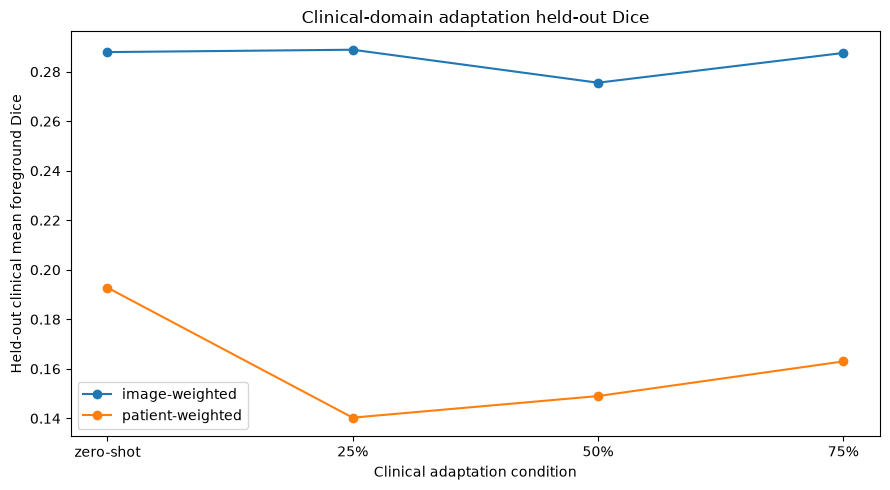

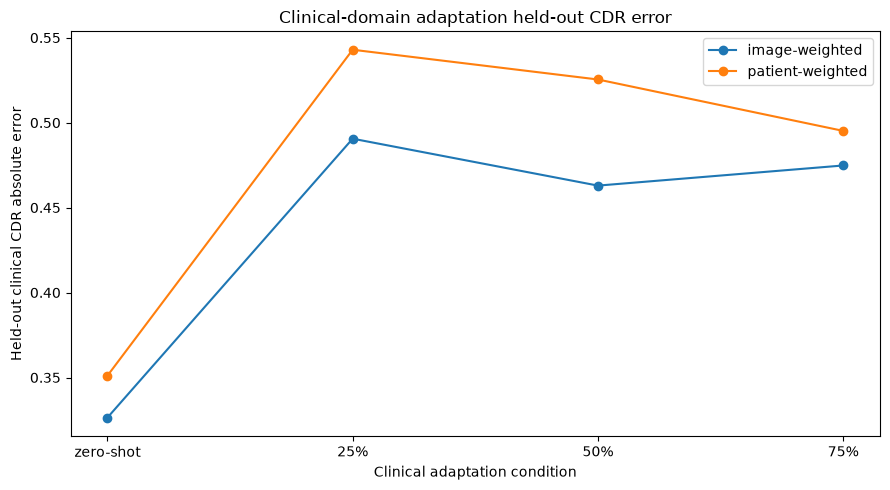

,condition,clinical_training_rows_used,clinical_training_groups_used,patient_weighted_mean_foreground_dice_mean,delta_vs_zero_shot_patient_weighted_mean_foreground_dice,patient_weighted_cdr_abs_error_mean,cdr_abs_error_improvement_vs_zero_shot_patient_weighted
0,zero_shot_notebook_10_on_clinical_test,0,0,0.192805,0.000000,0.351044,0.000000
1,clinical_adapt_25pct,16,3,0.140280,-0.052525,0.542934,-0.191890
2,clinical_adapt_50pct,22,6,0.148996,-0.043809,0.525417,-0.174373
3,clinical_adapt_75pct,27,9,0.162988,-0.029818,0.495163,-0.144120


In [16]:
# 12.16 — Clinical adaptation visualization

comparison = pd.read_csv(COMPARISON_SUMMARY_PATH)

plot_frame = comparison.copy()
plot_frame["label"] = plot_frame["condition"].replace(
    {
        "zero_shot_notebook_10_on_clinical_test": "zero-shot",
        "clinical_adapt_25pct": "25%",
        "clinical_adapt_50pct": "50%",
        "clinical_adapt_75pct": "75%",
    }
)

plt.figure(figsize=(9, 5))
plt.plot(
    plot_frame["label"],
    plot_frame["image_weighted_mean_foreground_dice_mean"],
    marker="o",
    label="image-weighted",
)
plt.plot(
    plot_frame["label"],
    plot_frame["patient_weighted_mean_foreground_dice_mean"],
    marker="o",
    label="patient-weighted",
)
plt.xlabel("Clinical adaptation condition")
plt.ylabel("Held-out clinical mean foreground Dice")
plt.title("Clinical-domain adaptation held-out Dice")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(
    plot_frame["label"],
    plot_frame["image_weighted_cdr_abs_error_mean"],
    marker="o",
    label="image-weighted",
)
plt.plot(
    plot_frame["label"],
    plot_frame["patient_weighted_cdr_abs_error_mean"],
    marker="o",
    label="patient-weighted",
)
plt.xlabel("Clinical adaptation condition")
plt.ylabel("Held-out clinical CDR absolute error")
plt.title("Clinical-domain adaptation held-out CDR error")
plt.legend()
plt.tight_layout()
plt.show()

display(
    comparison[
        [
            "condition",
            "clinical_training_rows_used",
            "clinical_training_groups_used",
            "patient_weighted_mean_foreground_dice_mean",
            "delta_vs_zero_shot_patient_weighted_mean_foreground_dice",
            "patient_weighted_cdr_abs_error_mean",
            "cdr_abs_error_improvement_vs_zero_shot_patient_weighted",
        ]
    ]
)


## 12.17 — Interpretation guide

Notebook 12 is an exploratory clinical-domain adaptation experiment. The held-out test groups are patient/encounter-group separated from the clinical training and validation groups.

The most important comparison is patient-weighted held-out clinical mean foreground Dice relative to the zero-shot Notebook 10 checkpoint on the same held-out test groups. CDR absolute error should be interpreted alongside Dice, because a model can improve mask overlap while still producing clinically unreliable cup-to-disc geometry.

In [17]:
# 12.17 — Final handoff summary

comparison = pd.read_csv(COMPARISON_SUMMARY_PATH)
run_metadata = pd.read_csv(RUN_METADATA_PATH)

best_patient_row = (
    comparison
    .sort_values(
        ["patient_weighted_mean_foreground_dice_mean", "image_weighted_mean_foreground_dice_mean"],
        ascending=[False, False],
    )
    .iloc[0]
    .to_dict()
)

best_image_row = (
    comparison
    .sort_values(
        ["image_weighted_mean_foreground_dice_mean", "patient_weighted_mean_foreground_dice_mean"],
        ascending=[False, False],
    )
    .iloc[0]
    .to_dict()
)

zero_row = comparison.loc[
    comparison["condition"] == "zero_shot_notebook_10_on_clinical_test"
].iloc[0].to_dict()

handoff = {
    "notebook": "12_clinical_domain_adaptation_experiments",
    "experiment_type": "clinical_domain_adaptation",
    "source_model_notebook": "10_long_training_selected_public_model",
    "clinical_split_rule": "patient_or_encounter_group_holdout",
    "heldout_test_rows": int(zero_row["heldout_test_rows"]),
    "heldout_test_groups": int(zero_row["heldout_test_groups"]),
    "zero_shot_patient_weighted_mean_foreground_dice": zero_row["patient_weighted_mean_foreground_dice_mean"],
    "zero_shot_patient_weighted_cdr_abs_error": zero_row["patient_weighted_cdr_abs_error_mean"],
    "best_patient_weighted_condition": best_patient_row["condition"],
    "best_patient_weighted_mean_foreground_dice": best_patient_row["patient_weighted_mean_foreground_dice_mean"],
    "best_patient_weighted_delta_vs_zero_shot": best_patient_row[
        "delta_vs_zero_shot_patient_weighted_mean_foreground_dice"
    ],
    "best_patient_weighted_cdr_abs_error": best_patient_row["patient_weighted_cdr_abs_error_mean"],
    "best_image_weighted_condition": best_image_row["condition"],
    "best_image_weighted_mean_foreground_dice": best_image_row["image_weighted_mean_foreground_dice_mean"],
    "best_image_weighted_delta_vs_zero_shot": best_image_row[
        "delta_vs_zero_shot_image_weighted_mean_foreground_dice"
    ],
    "next_notebook": "13_final_comparative_analysis.ipynb",
    "next_step": (
        "Synthesize public model selection, public robustness training, pure clinical generalization, "
        "and clinical-domain adaptation into final project figures and conclusions."
    ),
}

display(pd.DataFrame([handoff]).T.rename(columns={0: "value"}))


,value
notebook,12_clinical_domain_adaptation_experiments
experiment_type,clinical_domain_adaptation
source_model_notebook,10_long_training_selected_public_model
clinical_split_rule,patient_or_encounter_group_holdout
heldout_test_rows,19
heldout_test_groups,5
zero_shot_patient_weighted_mean_foreground_dice,0.192805
zero_shot_patient_weighted_cdr_abs_error,0.351044
best_patient_weighted_condition,zero_shot_notebook_10_on_clinical_test
best_patient_weighted_mean_foreground_dice,0.192805
